# 📘 Week 2 Assignment — Tesla Deliveries & Production Analysis (2015–2025)

**Topics Covered**
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Data Visualization
- Feature Selection
- Regression Models
- Model Evaluation & Comparison

---

### Objective

The objective of this project is to analyze Tesla's production and delivery trends between 2015 and 2025 and build machine learning models capable of predicting estimated vehicle deliveries using production-related features.

## Assignment Pipeline

The following machine learning pipeline was implemented in this assignment:

1. Load the dataset 
2. Understand theDataset
3. Outlier Detection Using IQR Method
4. Visualize Estimated Delivery Trends  
5. Visualize Production Unit Trends  
6. Analyze Battery Capacity Trends  
7. Perform Feature Selection  
8. Split Dataset into Training and Testing Sets  
9. Implement Linear Regression Model  
10. Implement Random Forest Model  
11. Implement Ridge Regression Model  
12. Compare Machine Learning Models  
13. Draw Final Results and Conclusions


**Step 1 —> Load the Dataset**

In this step, the dataset is imported using Pandas and stored inside a DataFrame;the dataset contains Tesla delivery, production, pricing, battery, and sustainability-related information collected between 2015 and 2025.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [5]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


**Step 2 —> Understanding the Dataset**

Basic dataset exploration is performed using:
- shape()-to determine the number of rows and columns
- columns-to attain the feature names
- info()-to have the data types
- describe()-to gain the statistical summaries

In [45]:
df.shape

(2640, 12)

In [44]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [9]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [10]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


**Step 3 —> Outlier Detection Using IQR Method**

In this step, outliers present in the Estimated_Deliveries feature were analyzed using the Interquartile Range (IQR) technique. Outlier detection is important because extreme values can affect the performance and accuracy of machine learning models.

The IQR method works by calculating the spread between the first quartile (Q1) and third quartile (Q3). Any data point lying below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR is considered an outlier.A boxplot was used to visually identify the distribution and presence of extreme delivery values in the dataset.

**Graph Analysis — Outliers in Estimated Deliveries**

The boxplot visualization shows the distribution of Tesla estimated deliveries across different records. Most delivery values are concentrated within a normal range, while a few higher delivery values appear as outliers.These outliers indicate unusually high delivery counts during certain periods or regions. Since the number of outliers is limited and meaningful for business analysis, the values were retained instead of removed.

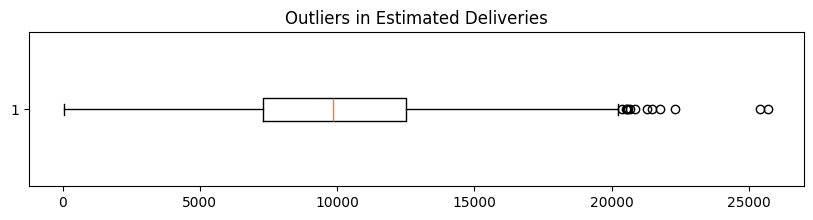

In [11]:
plt.figure(figsize=(10,2))
plt.boxplot(df['Estimated_Deliveries'],
            vert=False)
plt.title("Outliers in Estimated Deliveries")
plt.show()

**Step 4 —> Graph Analysis — Average Tesla Deliveries Over the Years**

This line graph represents the average estimated Tesla deliveries from 2015 to 2025. The visualization helps identify yearly delivery trends and fluctuations over time.The graph shows that Tesla deliveries remained relatively stable with slight increases and decreases across different years. A temporary dip is visible around 2020, followed by recovery in later years.This trend analysis helps understand Tesla’s market performance and production-demand relationship over time.

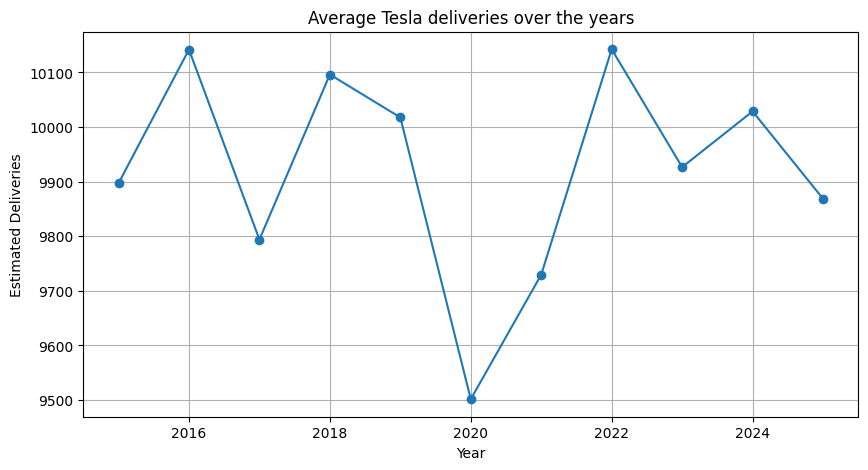

In [12]:
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].mean()
plt.figure(figsize=(10,5))
plt.plot(yearly_deliveries.index,
         yearly_deliveries.values,
         marker='o')
plt.title("Average Tesla deliveries over the years")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.grid(True)
plt.show()

**Step 5 —> Graph Analysis — Average Production Units Over the Years**

This graph illustrates the average number of production units manufactured between 2015 and 2025.The production trend generally follows the delivery trend, indicating that production levels were adjusted according to market demand. Slight fluctuations can be observed.The visualization helps analyze Tesla’s manufacturing consistency and yearly production performance.

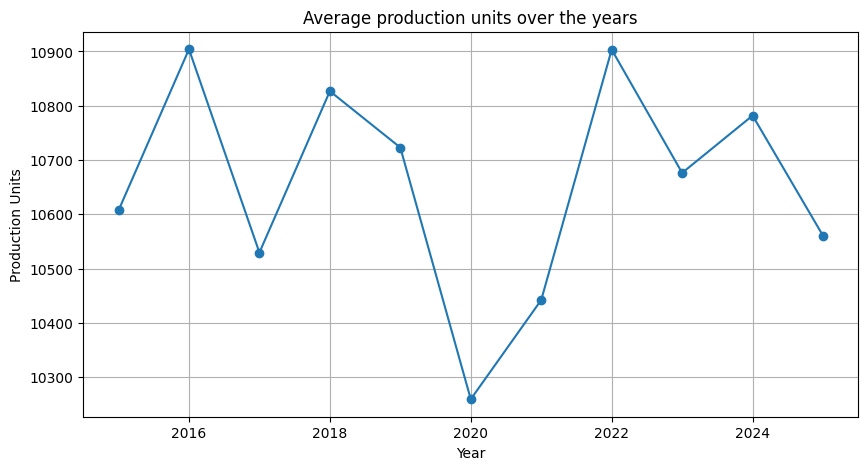

In [14]:
yearly_production = df.groupby('Year')['Production_Units'].mean()
plt.figure(figsize=(10,5))
plt.plot(yearly_production.index,
         yearly_production.values,
         marker='o')
plt.title("Average production units over the years")
plt.xlabel("Year")
plt.ylabel("Production Units")
plt.grid(True)
plt.show()

**Step 6 —> Graph Analysis — Battery Capacity Trend**

This graph shows the yearly average battery capacity trend of Tesla vehicles.Battery capacity remained comparatively stable over the years, with small variations in average values.The trend helps understand technological progression in Tesla vehicle batteries.

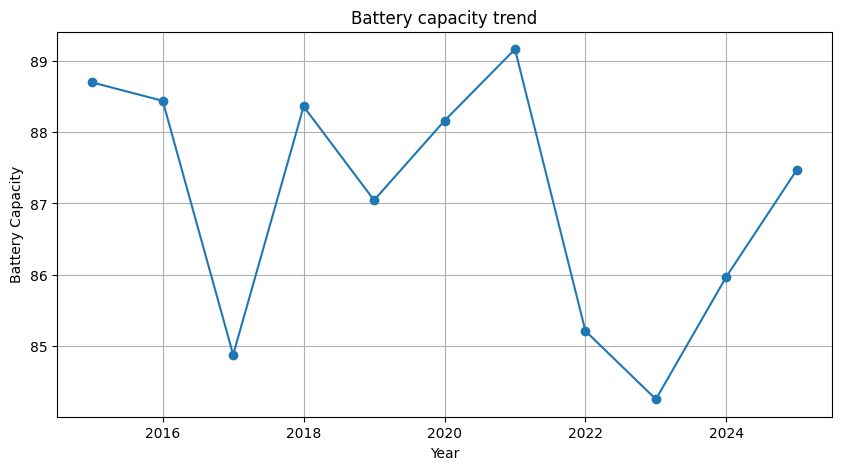

In [15]:
battery_trend = df.groupby('Year')['Battery_Capacity_kWh'].mean()
plt.figure(figsize=(10,5))
plt.plot(battery_trend.index,
         battery_trend.values,
         marker='o')
plt.title("Battery capacity trend")
plt.xlabel("Year")
plt.ylabel("Battery Capacity")
plt.grid(True)
plt.show()

**Step 7 —> Feature Selection**

In this step,important features relevant to delivery prediction were selected from the dataset.The selected input features were:
- Year
- Production_Units
- Avg_Price_USD
- Battery_Capacity_kWh

The target variable chosen for prediction was:
- Estimated_Deliveries

Feature selection helps improve model performance by using only the most relevant variables for prediction.

In [22]:
X = df[['Year',
        'Production_Units',
        'Avg_Price_USD',
        'Battery_Capacity_kWh']]

y = df['Estimated_Deliveries']

**Step 8 —> Data Splitting**

The dataset was divided into training and testing sets using the train_test_split() function from Scikit-learn.
- 80% of the data was used for training
- 20% of the data was used for testing
  
This step ensures that the machine learning models are evaluated on unseen data, helping measure their real-world prediction capability.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**Step 9 —> Model 1 — Linear Regression**

Linear Regression was implemented as the first machine learning model for predicting estimated Tesla deliveries.This model attempts to establish a linear relationship between the selected input features and the target variable.The following evaluation metrics were calculated:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- Mean Absolute Percentage Error (MAPE)

The model achieved a very high R² score, indicating strong predictive performance and a good fit to the dataset.

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
predictions = model.predict(X_test)

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

In [28]:
import numpy as np
lr_mae = mean_absolute_error(y_test, predictions)
lr_mse = mean_squared_error(y_test, predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, predictions)
lr_mape = mean_absolute_percentage_error(y_test, predictions)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression MSE:", lr_mse)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2 Score:", lr_r2)
print("Linear Regression MAPE:", lr_mape)

Linear Regression MAE: 338.9571653781007
Linear Regression MSE: 173092.07127627434
Linear Regression RMSE: 416.04335264041214
Linear Regression R2 Score: 0.9883879829960144
Linear Regression MAPE: 0.03740391615999828


**Step 10 —> Model 2 — Random Forest**

Random Forest was implemented as an ensemble-based machine learning model.This model combines multiple decision trees to improve prediction accuracy and reduce overfitting. Random Forest is effective for handling complex relationships and nonlinear patterns within data.The model performance was evaluated using:
- MAE
- MSE
- RMSE
- R² Score
- MAPE

The Random Forest model produced highly accurate predictions with strong overall performance.

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [30]:
rf_predictions = rf_model.predict(X_test)

In [31]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)
rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2 Score:", rf_r2)
print("Random Forest MAPE:", rf_mape)

Random Forest MAE: 368.99625000000003
Random Forest MSE: 215205.2007628788
Random Forest RMSE: 463.9021456760885
Random Forest R2 Score: 0.9855627907611316
Random Forest MAPE: 0.03843520293655243


**Step 11 —> Model 3 — Ridge Regression**

Ridge Regression was implemented to improve linear regression performance using regularization.This model helps reduce overfitting by adding a penalty term to the regression equation.Ridge Regression is especially useful when features are highly correlated.The model was evaluated using:
- MAE
- MSE
- RMSE
- R² Score
- MAPE

The Ridge Regression model achieved results very similar to Linear Regression, showing stable and reliable prediction capability.

In [34]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [36]:
ridge_predictions = ridge_model.predict(X_test)

In [38]:
ri_mae = mean_absolute_error(y_test, ridge_predictions)
ri_mse = mean_squared_error(y_test, ridge_predictions)
ri_rmse = np.sqrt(ridge_mse)
ri_r2 = r2_score(y_test, ridge_predictions)
ri_mape = mean_absolute_percentage_error(y_test, ridge_predictions)

print("Ridge Regression MAE:", ri_mae)
print("Ridge Regression MSE:", ri_mse)
print("Ridge Regression RMSE:", ri_rmse)
print("Ridge Regression R2 Score:", ri_r2)
print("Ridge Regression MAPE:", ri_mape)

Ridge Regression MAE: 338.9571604315352
Ridge Regression MSE: 173092.0665263166
Ridge Regression RMSE: 416.04334693192317
Ridge Regression R2 Score: 0.9883879833146689
Ridge Regression MAPE: 0.037403916473499284


**Step 12 —> Model Comparison**

A comparison table was created to evaluate the performance of all implemented machine learning models.The comparison was based on the metrics:
- MAE
- RMSE
- R² Score
- MAPE

Among the tested models, Linear Regression and Ridge Regression produced the best performance with the highest R² scores and lowest prediction errors.Random Forest also performed well but showed slightly higher error values compared to the regression-based models.

In [47]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression","Ridge Regression","Random Forest"],
    "MAE": [lr_mae,ri_mae,rf_mae],
    "RMSE": [lr_rmse,ri_rmse,rf_rmse],
    "R2 Score": [lr_r2,ri_r2,rf_r2],
    "MAPE": [lr_mape,ri_mape,rf_mape]
})

comparison

,Model,MAE,RMSE,R2 Score,MAPE
0,Linear Regression,338.957165,416.043353,0.988388,0.037404
1,Ridge Regression,338.957160,416.043347,0.988388,0.037404
2,Random Forest,368.996250,463.902146,0.985563,0.038435


**Step 13 —> Final Results and Conclusion**

The assignment does showacse successfully analyzed Tesla production and delivery trends from 2015 to 2025 using Exploratory Data Analysis (EDA), visualization techniques and machine learning models.

Key outcomes of the project include:
- Successful dataset preprocessing and analysis
- Identification of trends and outliers
- Visualization of deliveries, production units and battery capacity
- Implementation of multiple regression models
- Accurate prediction of estimated deliveries

Among all models, Linear Regression and Ridge Regression achieved the best overall performance with very high R² scores and low prediction errors.